# UniverSeg Baseline on Brain Tumour Dataset (BraTS)

This notebook evaluates the pretrained UniverSeg model on 2D slices from the 4D Brain Tumour (BraTS) dataset.

In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('external/universeg'))
sys.path.append(os.path.abspath('.'))
from universeg import universeg


## 1. Load Processed Dataset & Select FLAIR Channel

In [2]:
images_path = 'data/processed/braintumour_images.npy'
masks_path = 'data/processed/braintumour_masks.npy'

images_4d = np.load(images_path, mmap_mode='r')
masks_3d = np.load(masks_path, mmap_mode='r')

print('Images 4D shape:', images_4d.shape)
print('Masks 3D shape:', masks_3d.shape)

# LIMITATION NOTE:
# UniverSeg expects single-channel (grayscale) 2D images, not 4-channel MRI tensors.
# For this initial baseline test, we extract only the FLAIR modality (channel index 0),
# which is commonly used alone for tumor visibility.
# Note on limitation: full multimodal fusion (combining FLAIR, T1, T1gd, T2) is left as future work.
# This baseline evaluates single-channel cross-modality generalization of UniverSeg.
flair_images = images_4d[:, :, :, 0]


Images 4D shape: (31527, 240, 240, 4)
Masks 3D shape: (31527, 240, 240)


## 2. Sample Support & Test Sets

In [3]:
rng = np.random.RandomState(42)
selected_indices = rng.choice(len(flair_images), size=7, replace=False)
support_indices = selected_indices[:2]
test_indices = selected_indices[2:]

print('Support slice indices:', support_indices)
print('Test slice indices:', test_indices)

support_imgs = flair_images[support_indices]
support_lbls = masks_3d[support_indices]
test_imgs = flair_images[test_indices]
test_lbls = masks_3d[test_indices]


Support slice indices: [27030 14401]
Test slice indices: [31152 28718  5500 25571  9134]


## 3. Run UniverSeg Inference

In [4]:
num_test = len(test_indices)
test_img_t = torch.tensor(test_imgs, dtype=torch.float32).unsqueeze(1)
support_img_t = torch.tensor(support_imgs, dtype=torch.float32).unsqueeze(1).unsqueeze(0).repeat(num_test, 1, 1, 1, 1)
support_lbl_t = torch.tensor(support_lbls, dtype=torch.float32).unsqueeze(1).unsqueeze(0).repeat(num_test, 1, 1, 1, 1)

model = universeg(pretrained=True)
model.eval()

with torch.no_grad():
    logits = model(test_img_t, support_img_t, support_lbl_t)
    probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
    preds = (probs > 0.5).astype(np.float32)


## 4. Compute Dice Scores & Visualize Results

Test Slice 1 (Index 31152): Dice = 0.3052
Test Slice 2 (Index 28718): Dice = 0.2646
Test Slice 3 (Index 5500): Dice = 0.0036
Test Slice 4 (Index 25571): Dice = 0.0000
Test Slice 5 (Index 9134): Dice = 0.0144

Average Dice Score: 0.1176


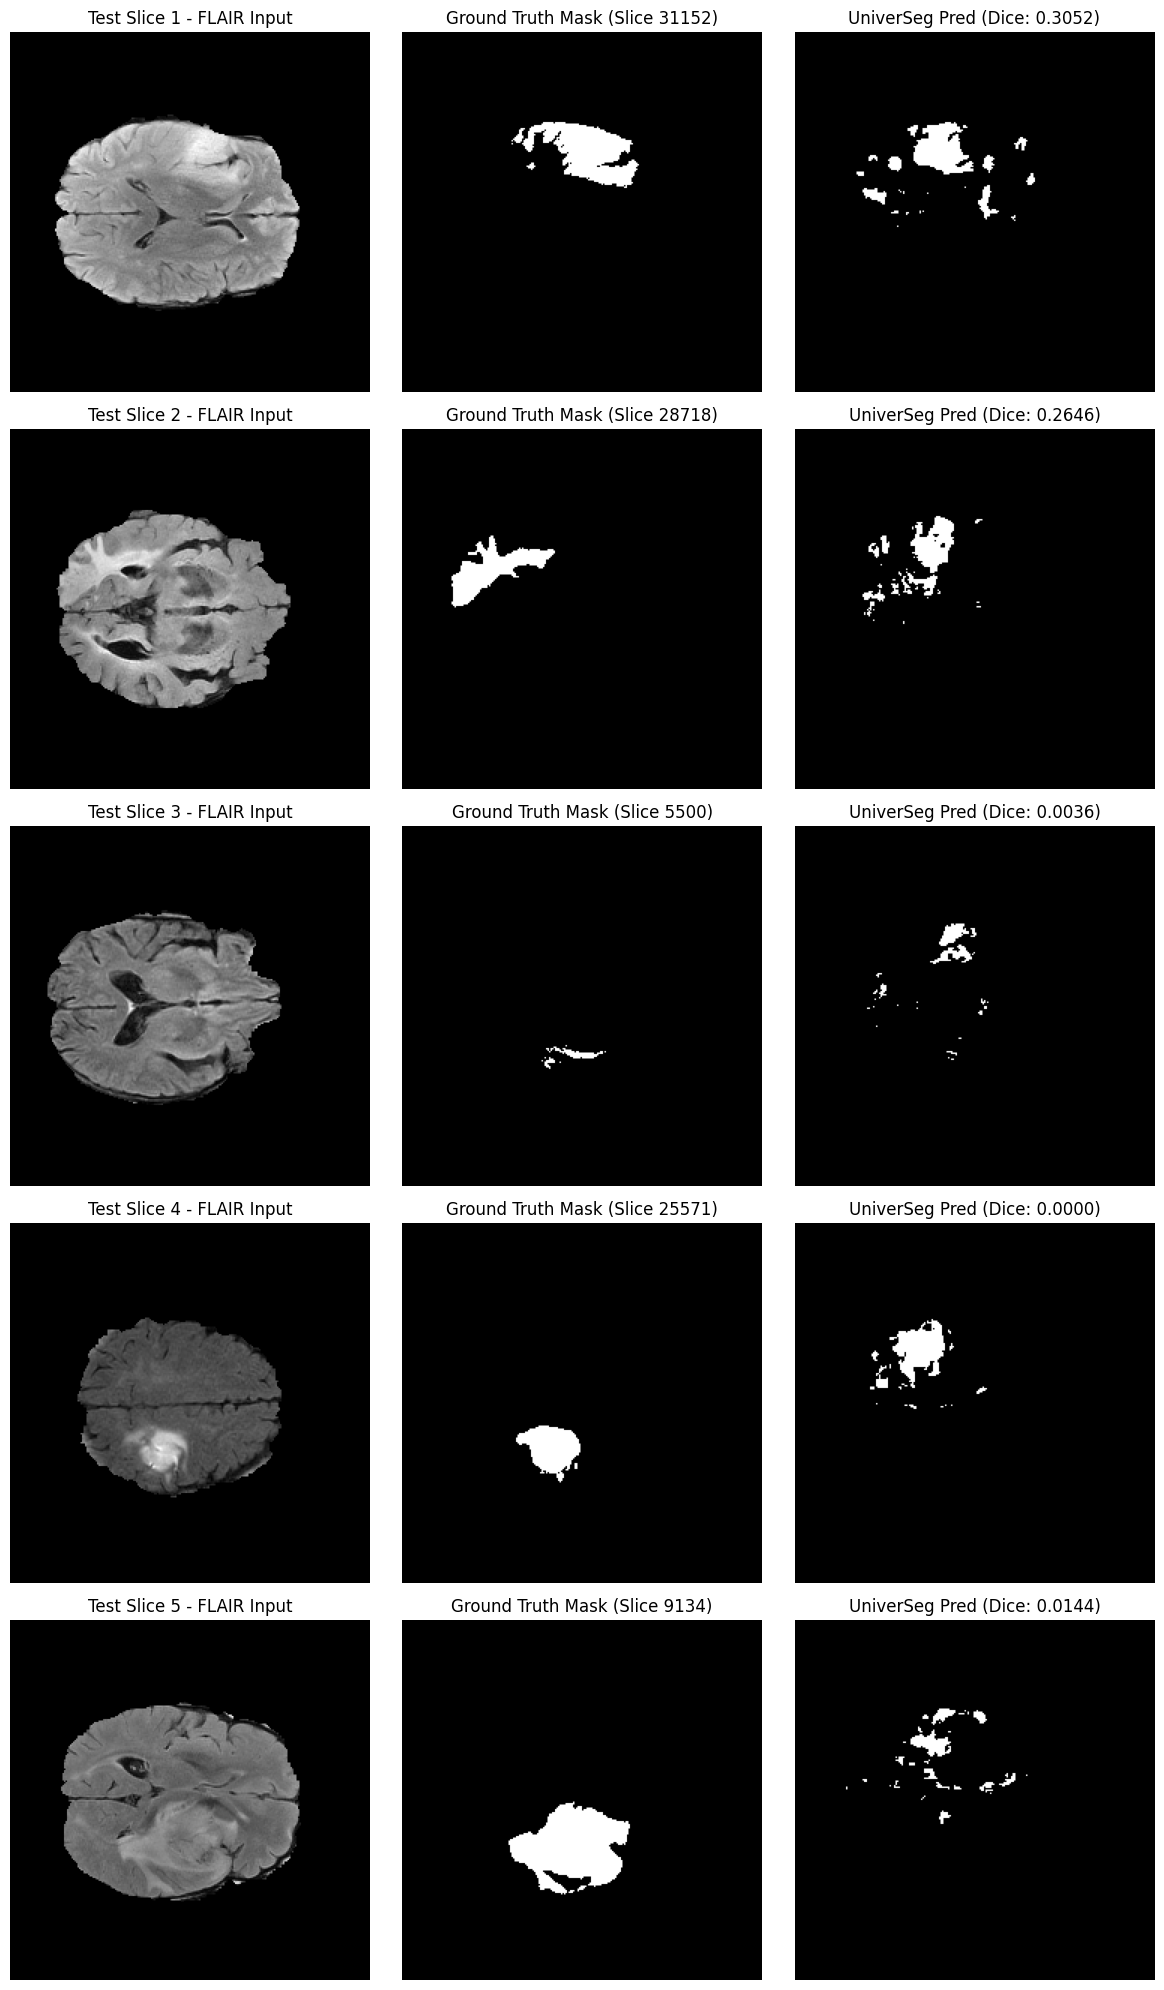

In [5]:
def compute_dice(pred, target, eps=1e-8):
    intersection = np.sum(pred * target)
    total = np.sum(pred) + np.sum(target)
    return float((2.0 * intersection + eps) / (total + eps))

dice_scores = [compute_dice(preds[i], test_lbls[i]) for i in range(num_test)]
for i, d in enumerate(dice_scores):
    print(f'Test Slice {i+1} (Index {test_indices[i]}): Dice = {d:.4f}')

avg_dice = np.mean(dice_scores)
print(f'\nAverage Dice Score: {avg_dice:.4f}')

fig, axes = plt.subplots(num_test, 3, figsize=(12, 4 * num_test))
for i in range(num_test):
    axes[i, 0].imshow(test_imgs[i], cmap='gray')
    axes[i, 0].set_title(f'Test Slice {i+1} - FLAIR Input')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(test_lbls[i], cmap='bone')
    axes[i, 1].set_title(f'Ground Truth Mask (Slice {test_indices[i]})')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(preds[i], cmap='bone')
    axes[i, 2].set_title(f'UniverSeg Pred (Dice: {dice_scores[i]:.4f})')
    axes[i, 2].axis('off')

plt.tight_layout()
os.makedirs('logs', exist_ok=True)
plt.savefig('logs/braintumour_baseline_results.png', bbox_inches='tight', dpi=150)
plt.show()
